<h1>Train — AlexNet</h1>

Trains and evaluates AlexNet **from scratch (no ImageNet pretraining)** using the hand-picked hyperparameters from `ARCH_HYPERPARAMS["alexnet"]`, then saves its results and weights to disk for the results notebook. Unlike every other architecture here, this one starts from random weights instead of a pretrained backbone -- included to see how a small CNN trained from scratch on this dataset compares to the transfer-learning models.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1803 | Val: 440 | Test: 284


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["alexnet"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"AlexNet: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

AlexNet: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (AlexNet, trained from scratch -- no pretrained weights)
# ---------------------------------------------------------
model = models.alexnet(weights=None)  # no ImageNet pretraining, unlike every other architecture here

# AlexNet's classifier is nn.Sequential(Dropout, Linear, ReLU, Dropout, Linear,
# ReLU, Linear) — swap out just the final Linear layer (index 6) for our
# (optionally deeper) classifier head, same as the fc/classifier swaps used
# for the other architectures.
in_f = model.classifier[6].in_features
model.classifier[6] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[AlexNet] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[AlexNet] Epoch   1/100 | LR: 1.00e-04 | train loss 1.3039 acc 0.436 | val loss 1.1210 acc 0.484 *


[AlexNet] Epoch   2/100 | LR: 1.00e-04 | train loss 1.1233 acc 0.493 | val loss 1.0157 acc 0.532 *


[AlexNet] Epoch   3/100 | LR: 1.00e-04 | train loss 1.0066 acc 0.528 | val loss 0.9805 acc 0.514 *


[AlexNet] Epoch   4/100 | LR: 1.00e-04 | train loss 0.9522 acc 0.555 | val loss 0.7720 acc 0.645 *


...

[AlexNet] Epoch  96/100 | LR: 1.00e-10 | train loss 0.4729 acc 0.768 | val loss 0.5461 acc 0.770


[AlexNet] Epoch  97/100 | LR: 1.00e-10 | train loss 0.4805 acc 0.776 | val loss 0.5461 acc 0.770


[AlexNet] Epoch  98/100 | LR: 1.00e-10 | train loss 0.4724 acc 0.771 | val loss 0.5461 acc 0.770


[AlexNet] Epoch  99/100 | LR: 1.00e-10 | train loss 0.4718 acc 0.768 | val loss 0.5461 acc 0.770


[AlexNet] Epoch 100/100 | LR: 1.00e-10 | train loss 0.4599 acc 0.771 | val loss 0.5461 acc 0.770

[AlexNet] Restored best checkpoint (val loss = 0.5441)


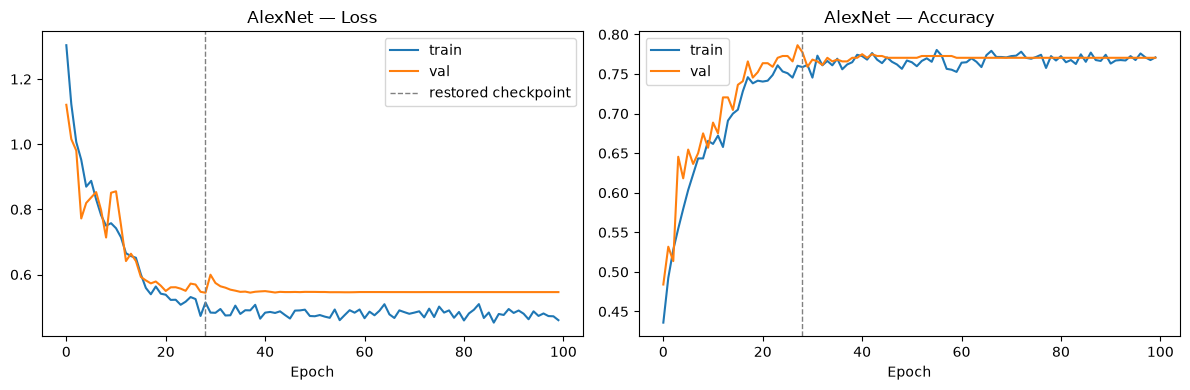

In [4]:
# No early stopping (patience=None): from random init AlexNet can sit on a
# ~ln(4) loss plateau for many epochs before it starts learning, and noisy
# val loss during that plateau made early stopping quit too soon.
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, None, "AlexNet", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "AlexNet")

## Evaluate on the test set

[AlexNet] Test accuracy: 0.754


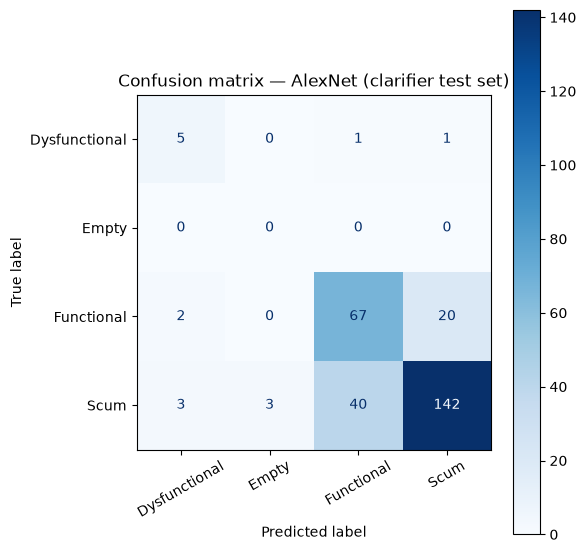

               precision    recall  f1-score   support

Dysfunctional      0.500     0.714     0.588         7
        Empty      0.000     0.000     0.000         0
   Functional      0.620     0.753     0.680        89
         Scum      0.871     0.755     0.809       188

     accuracy                          0.754       284
    macro avg      0.498     0.556     0.519       284
 weighted avg      0.783     0.754     0.763       284

  [warn] 'Empty' has 0 examples in this test set — AUC undefined, skipping.


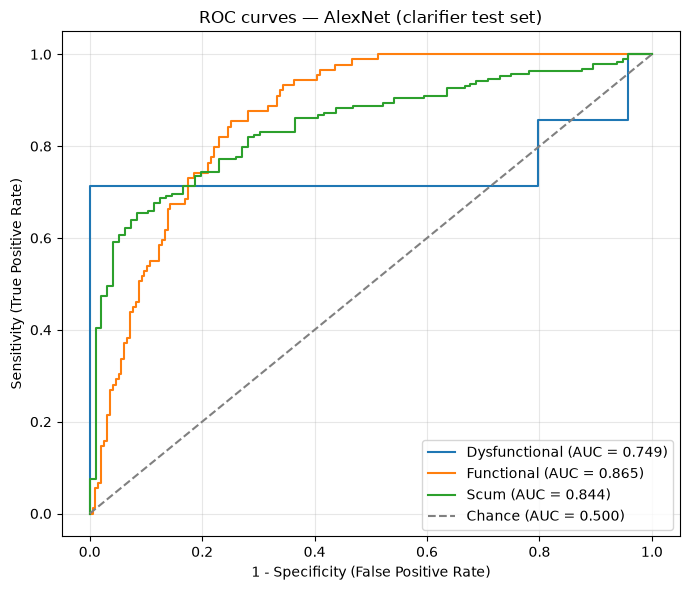

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.749
  Empty          : undefined (0 examples)
  Functional     : 0.865
  Scum           : 0.844

Mean AUC (over 3/4 classes with test examples): 0.819


(np.float64(0.7535211267605634),
 {'Dysfunctional': 0.7493553378029912,
  'Empty': nan,
  'Functional': 0.8650532987611639,
  'Scum': 0.8438054078014184})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "AlexNet", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("AlexNet", "alexnet")

Saved results to ../results/clarifier_aug/results_clarifier_alexnet_Waterval.pkl


Saved model weights to ../models/clarifier_alexnet_cnn.pt
